In [44]:
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import json
from tqdm import tqdm
import torch
import torch.nn.functional as F
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import sys
sys.path.append('../..')
from style_setup import set_thesis_style
set_thesis_style()

# Analysis

## Model data

In [46]:
print(ppl_files)

['/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/small/ppl/dolly_test_Llama_ppl.jsonl', '/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/small/ppl/generation_results_lora_llama_8b_multi_v3_ppl.jsonl', '/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/small/ppl/generation_results_lora_llama_8b_single_v8_ppl.jsonl', '/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/small/ppl/generation_results_lora_llama_8b_human_v3_ppl.jsonl']


dolly_test_Llama_ppl.jsonl
generation_results_lora_llama_8b_multi_v3_ppl.jsonl
generation_results_lora_llama_8b_single_v8_ppl.jsonl
generation_results_lora_llama_8b_human_v3_ppl.jsonl


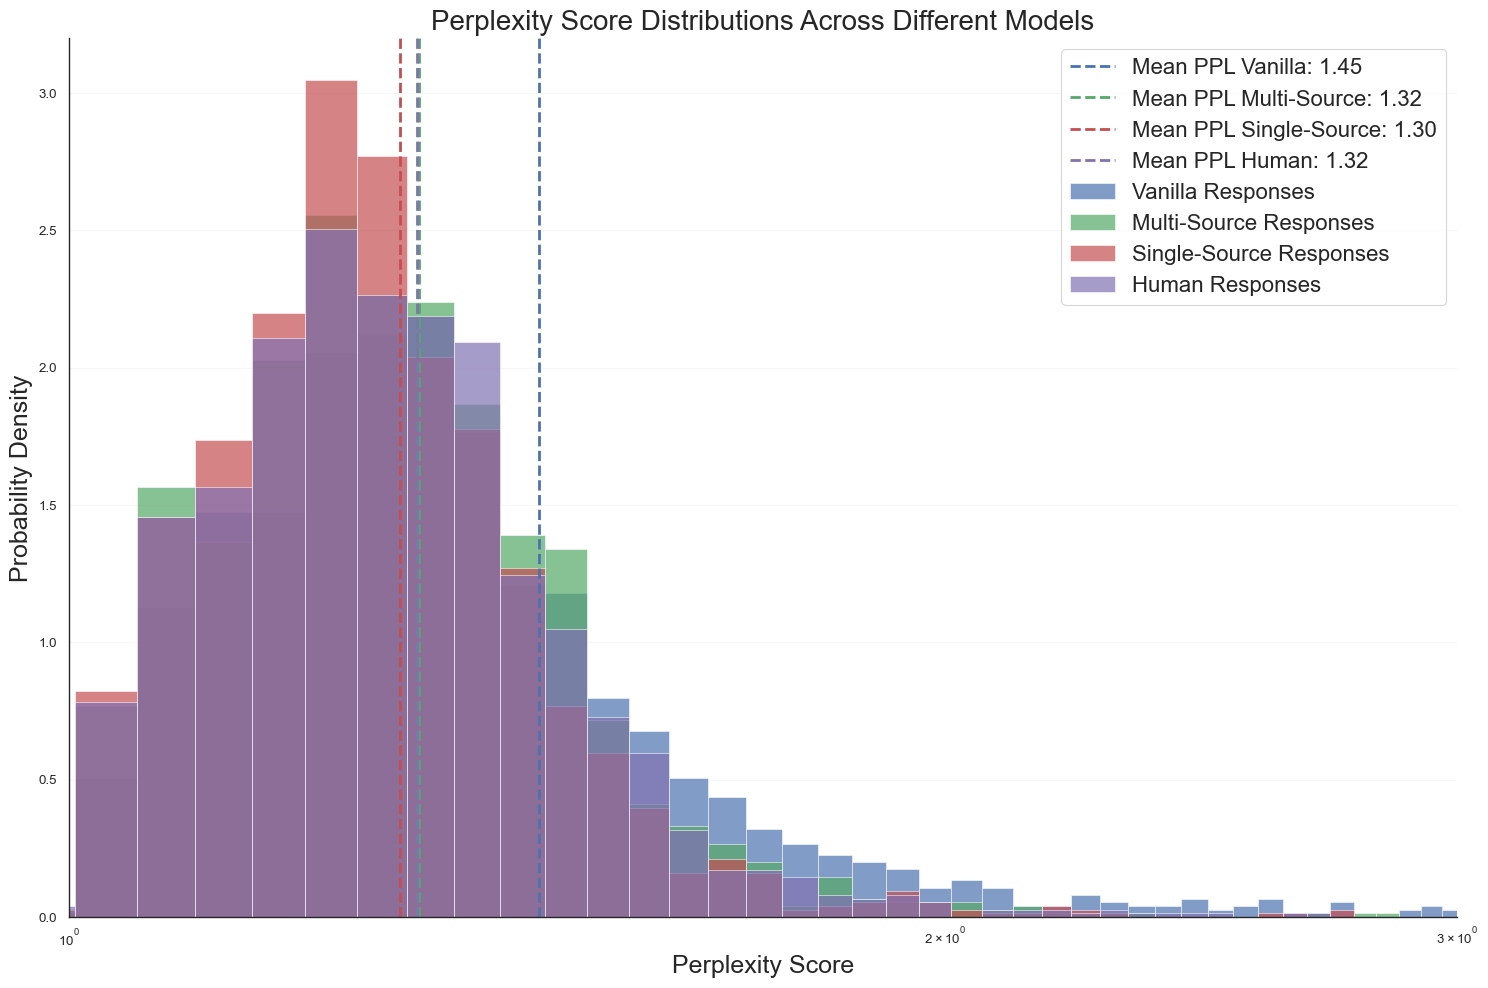

In [49]:
# Get all perplexity files
ppl_files = glob.glob("/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/small/ppl/*_ppl.jsonl")


# Extract perplexity values
perplexities_by_file = {}
for file in ppl_files:
    file_name = os.path.basename(file)
    perplexities_by_file[file_name] = []
    with open(file, 'r') as f:
        for line in f:
            data = json.loads(line)
            data = data["token_probabilities_Llama-3.1-8B-Instruct"]
            perplexities_by_file[file_name].append(data['perplexity'])

dataset_names = ["Vanilla","Multi-Source", "Single-Source", "Human"]

xmin = 1
plt.figure(figsize=(15, 10))

# Set bins for histogram
bins = np.linspace(0, 10, 200)

# Calculate means for each file
means = {}
for file_name, perplexities in perplexities_by_file.items():
    print(file_name)
    means[file_name] = np.mean(perplexities)

# Plot histograms for each file
colors = sns.color_palette()
for i, (file_name, perplexities) in enumerate(perplexities_by_file.items()):
    # Use dataset_names for labels instead of extracting from filename
    sns.histplot(perplexities, bins=bins, alpha=0.7, 
                label=f'{dataset_names[i]} Responses', 
                color=colors[i], 
                stat='density')

# Add vertical lines for mean values
for i, (file_name, mean) in enumerate(means.items()):
    plt.axvline(x=mean, color=colors[i], linestyle='--', linewidth=2, 
                label=f'Mean PPL {dataset_names[i]}: {mean:.2f}')

# Add labels and title
plt.xlabel('Perplexity Score', fontsize=18)
plt.ylabel('Probability Density', fontsize=18)
plt.title('Perplexity Score Distributions Across Different Models', fontsize=20)
plt.xlim(xmin, xmax)
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

#plt.savefig("../../plots/exp_1/ppl_distributions_small_with_mean.png")

plt.tight_layout()
plt.show()


/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_48823/37291379.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=data, palette=sns.color_palette())
/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_48823/37291379.py:28: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(x=labels, y=data, palette=sns.color_palette())
/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_48823/37291379.py:40: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 5)


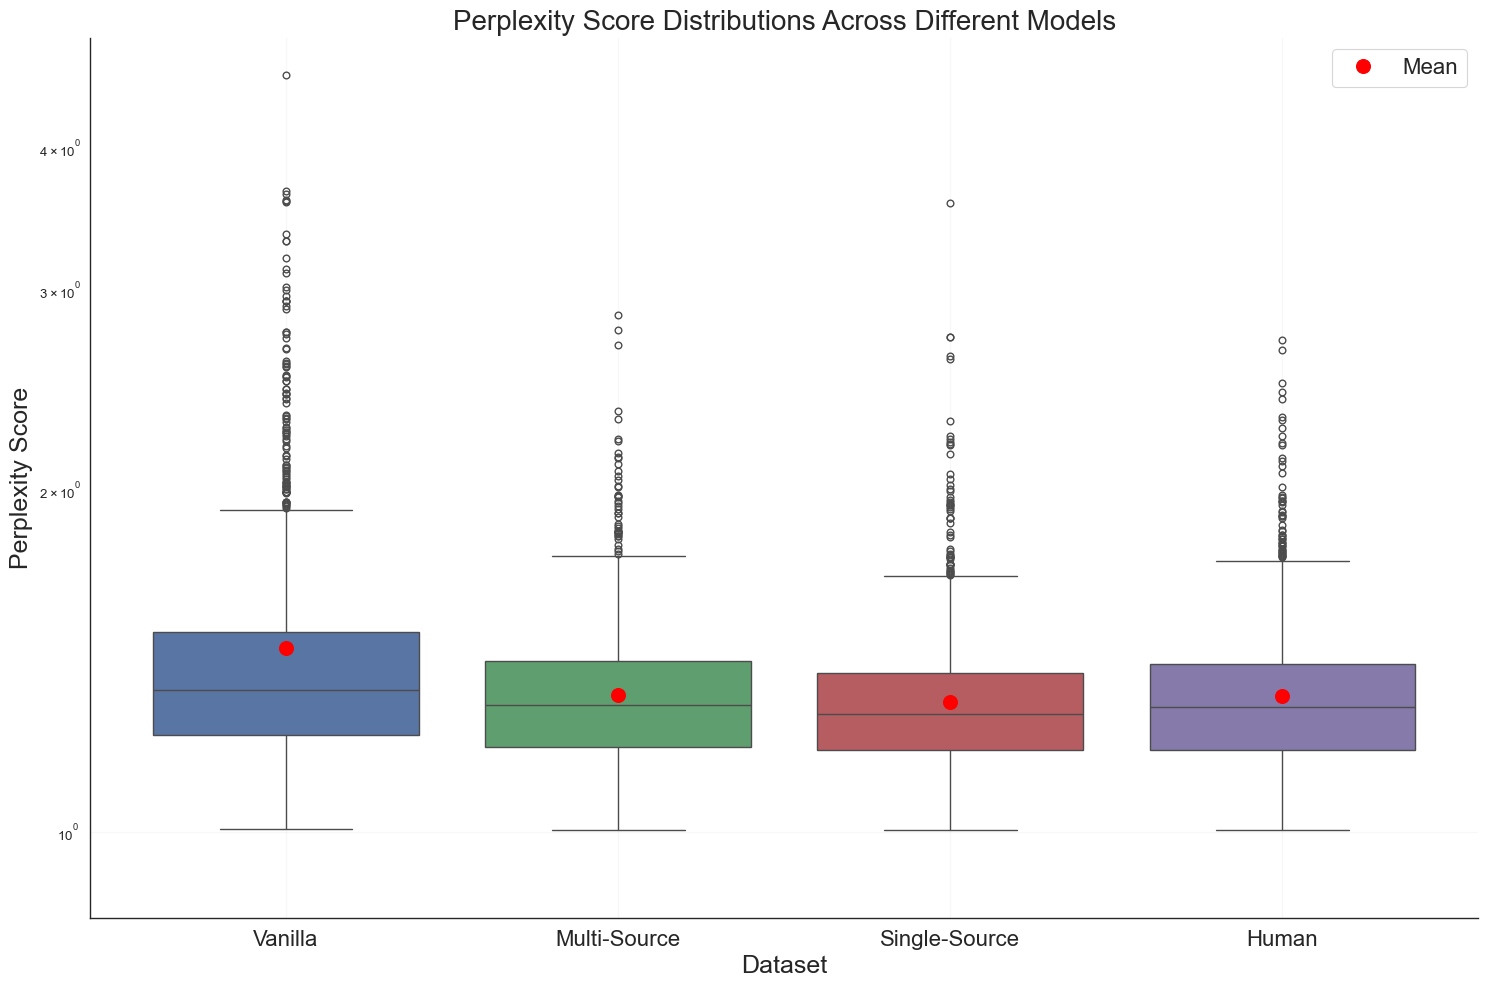

In [51]:
# Get all perplexity files
ppl_files = glob.glob("/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/small/ppl/*_ppl.jsonl")

# Extract perplexity values
perplexities_by_file = {}
for file in ppl_files:
    file_name = os.path.basename(file)
    perplexities_by_file[file_name] = []
    with open(file, 'r') as f:
        for line in f:
            data = json.loads(line)
            data = data["token_probabilities_Llama-3.1-8B-Instruct"]
            perplexities_by_file[file_name].append(data['perplexity'])

dataset_names = ["Vanilla","Multi-Source", "Single-Source", "Human"]

# Create figure for box plots
plt.figure(figsize=(15, 10))

# Prepare data for box plot
data = []
labels = []
for i, (file_name, perplexities) in enumerate(perplexities_by_file.items()):
    data.extend(perplexities)
    labels.extend([dataset_names[i]] * len(perplexities))

# Create box plot
sns.boxplot(x=labels, y=data, palette=sns.color_palette())

# Add mean points
for i, (file_name, perplexities) in enumerate(perplexities_by_file.items()):
    mean_val = np.mean(perplexities)
    plt.plot(i, mean_val, 'o', color='red', markersize=10, label='Mean' if i == 0 else "")

# Add labels and title
plt.xlabel('Dataset', fontsize=18)
plt.ylabel('Perplexity Score', fontsize=18)
plt.title('Perplexity Score Distributions Across Different Models', fontsize=20)
plt.yscale('log')
plt.ylim(0, 5)
plt.grid(alpha=0.3)
plt.legend(fontsize=16)

# Set x-tick labels to be larger
plt.xticks(fontsize=16)

#plt.savefig("../../plots/exp_1/box_ppl_distributions_small_ylim5.png")

plt.tight_layout()
plt.show()


In [52]:
from scipy import stats

# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [perplexities for perplexities in perplexities_by_file.values()]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(dataset_names)):
        for j in range(i + 1, len(dataset_names)):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 115.02
p-value: 9.11e-25

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

Vanilla vs Multi-Source:
U-statistic: 1296103.50
p-value: 1.52e-12
Significant difference: Yes

Vanilla vs Single-Source:
U-statistic: 1370697.00
p-value: 1.77e-24
Significant difference: Yes

Vanilla vs Human:
U-statistic: 1305552.50
p-value: 8.02e-14
Significant difference: Yes

Multi-Source vs Single-Source:
U-statistic: 1208107.50
p-value: 7.51e-04
Significant difference: Yes

Multi-Source vs Human:
U-statistic: 1138766.50
p-value: 6.51e-01
Significant difference: No

Single-Source vs Human:
U-statistic: 1059193.00
p-value: 3.79e-03
Significant difference: Yes


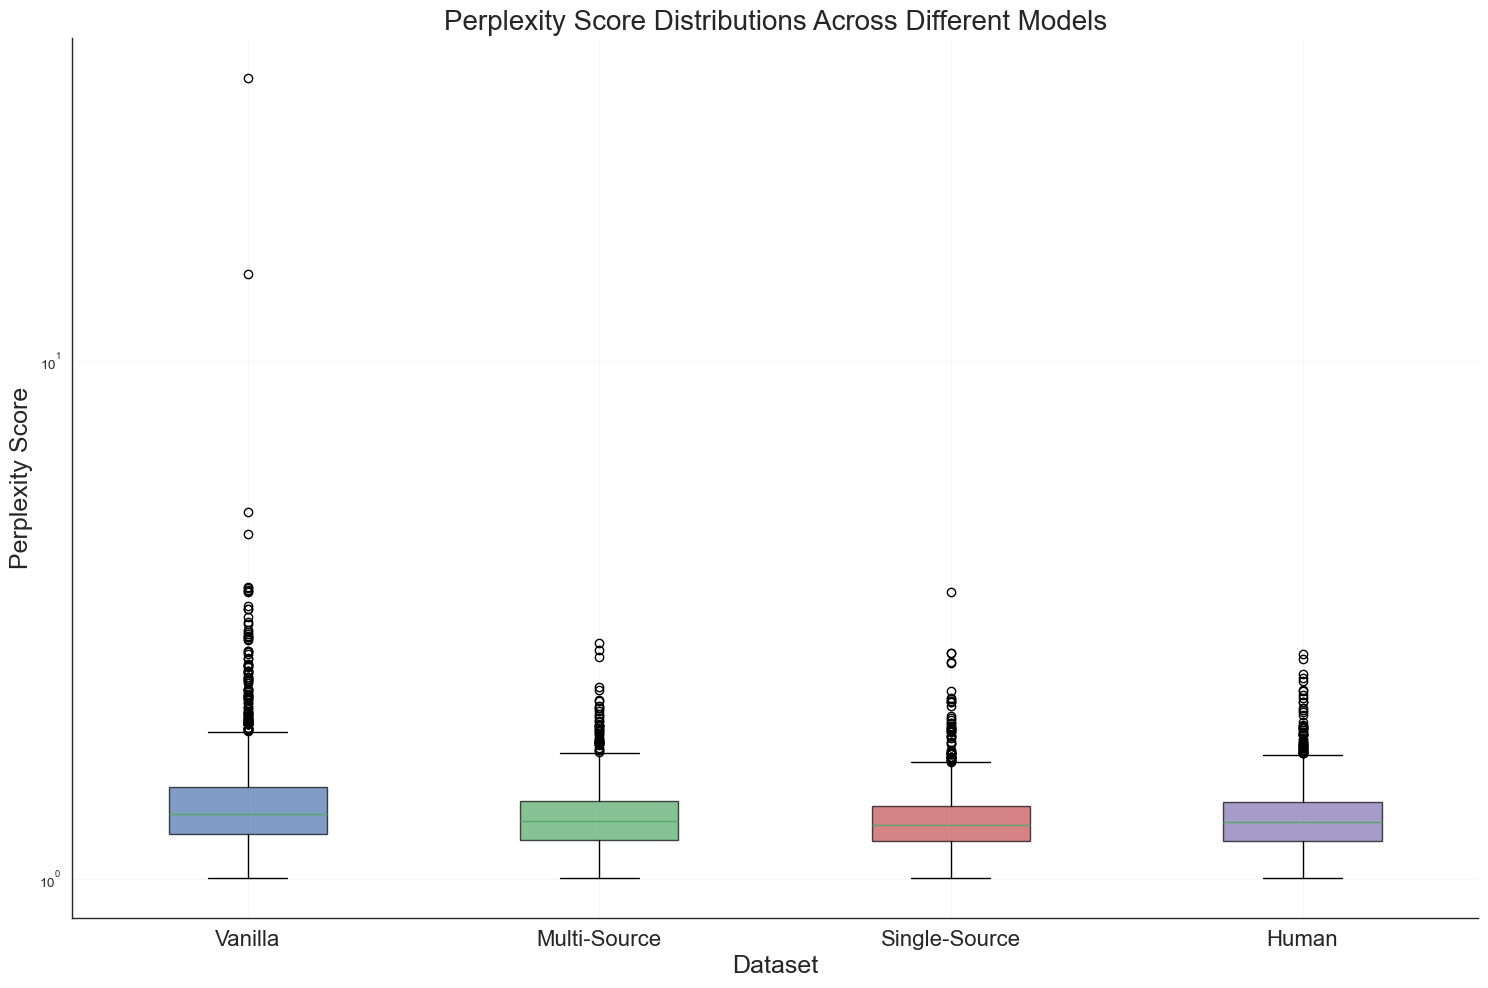

In [53]:
# Get all perplexity files
ppl_files = glob.glob("/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/small/ppl/*_ppl.jsonl")

# Extract perplexity values
perplexities_by_file = {}
for file in ppl_files:
    file_name = os.path.basename(file)
    perplexities_by_file[file_name] = []
    with open(file, 'r') as f:
        for line in f:
            data = json.loads(line)
            data = data["token_probabilities_Llama-3.1-8B-Instruct"]
            perplexities_by_file[file_name].append(data['perplexity'])


# Create figure for box plots
plt.figure(figsize=(15, 10))

# Prepare data for box plot
box_data = [perplexities for perplexities in perplexities_by_file.values()]

# Create box plot
box_plot = plt.boxplot(box_data, tick_labels=dataset_names, patch_artist=True)

# Customize box plot colors
colors = sns.color_palette()
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize plot
plt.xlabel('Dataset', fontsize=18)
plt.ylabel('Perplexity Score', fontsize=18)
plt.title('Perplexity Score Distributions Across Different Models', fontsize=20)
plt.yscale('log')
plt.grid(alpha=0.3)

# Set x-tick labels to larger font size
plt.xticks(fontsize=16)

plt.tight_layout()
plt.show()


In [54]:

# Calculate and display statistics
print("\nPerplexity Statistics:")
print("-" * 50)
for i, (name, perplexities) in enumerate(zip(dataset_names, box_data)):
    mean = np.mean(perplexities)
    variance = np.var(perplexities)
    print(f"{name}:")
    print(f"  Mean: {mean:.4f}")
    print(f"  Variance: {variance:.4f}")
    print(f"  Standard Deviation: {np.sqrt(variance):.4f}")
    print()



Perplexity Statistics:
--------------------------------------------------
Vanilla:
  Mean: 1.4512
  Variance: 1.0116
  Standard Deviation: 1.0058

Multi-Source:
  Mean: 1.3198
  Variance: 0.0403
  Standard Deviation: 0.2007

Single-Source:
  Mean: 1.3000
  Variance: 0.0402
  Standard Deviation: 0.2006

Human:
  Mean: 1.3179
  Variance: 0.0407
  Standard Deviation: 0.2017



[[1.24941, 1.07649, 1.34836, 1.72952, 1.3803, 1.75301, 1.06879, 1.16666, 1.31845, 1.25202, 1.23401, 1.39788, 1.11935, 1.15099, 2.09333, 1.20952, 1.22007, 1.99296, 1.29116, 1.17052, 1.14404, 1.50736, 1.25357, 1.50804, 1.31795, 1.88944, 1.33994, 1.40299, 1.34003, 1.30309, 1.3834, 1.43442, 1.27945, 1.16651, 1.41224, 1.35442, 1.30861, 1.88421, 1.27615, 1.24786, 1.12342, 1.32421, 1.44814, 1.40602, 1.38891, 1.38837, 1.47675, 1.40555, 1.35785, 1.09469, 1.24091, 1.17457, 1.41126, 1.23862, 1.80244, 1.14942, 1.61191, 1.40565, 1.39511, 1.29145, 1.1255, 1.39427, 1.11906, 1.81086, 1.38674, 1.10736, 1.22857, 1.23429, 1.3525, 1.39535, 1.39475, 1.31464, 1.18986, 1.09123, 1.22479, 1.20833, 1.10501, 1.12561, 1.01284, 1.67325, 1.28142, 1.16878, 1.21166, 1.48504, 1.07374, 1.32757, 1.58423, 1.5272, 1.40733, 1.22429, 1.24975, 1.58297, 1.05378, 1.22173, 1.19811, 1.28507, 1.36692, 1.35395, 1.61314, 1.13245, 1.43841, 2.21021, 2.42826, 1.08576, 1.26721, 1.24816, 2.43412, 1.23882, 1.47134, 1.51539, 2.58374, 1.15

In [55]:
# Perform Levene's test for homogeneity of variances
from scipy import stats

# Create a list of all perplexity arrays
all_perplexities = list(perplexities_by_file.values())
all_names = dataset_names  # Use dataset_names instead of perplexities_by_file.keys()



# Perform Levene's test
statistic, p_value = stats.levene(*all_perplexities)

print("\nLevene's Test for Homogeneity of Variances:")
print("-" * 50)
print(f"Test Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.4e}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nThe differences in variance between datasets are statistically significant")
    print("(p < 0.05)")
else:
    print("\nThe differences in variance between datasets are not statistically significant")
    print("(p >= 0.05)")

# Perform pairwise Levene's tests
print("\nPairwise Levene's Tests:")
print("-" * 50)
for i in range(len(all_names)):
    for j in range(i+1, len(all_names)):
        stat, p_val = stats.levene(all_perplexities[i], all_perplexities[j])
        print(f"{all_names[i]} vs {all_names[j]}:")
        print(f"  p-value: {p_val:.4e}")
        if p_val < alpha:
            print("  Significant difference in variance")
        else:
            print("  No significant difference in variance")
        print()



Levene's Test for Homogeneity of Variances:
--------------------------------------------------
Test Statistic: 16.7204
p-value: 8.1598e-11

The differences in variance between datasets are statistically significant
(p < 0.05)

Pairwise Levene's Tests:
--------------------------------------------------
Vanilla vs Multi-Source:
  p-value: 5.9383e-05
  Significant difference in variance

Vanilla vs Single-Source:
  p-value: 9.4370e-06
  Significant difference in variance

Vanilla vs Human:
  p-value: 6.0884e-05
  Significant difference in variance

Multi-Source vs Single-Source:
  p-value: 4.4624e-02
  Significant difference in variance

Multi-Source vs Human:
  p-value: 9.8042e-01
  No significant difference in variance

Single-Source vs Human:
  p-value: 4.3209e-02
  Significant difference in variance

